# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [506]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [507]:
# Load data
df = pd.read_csv('../data/01_raw/bank_transactions_data_edited.csv')

In [508]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [509]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [510]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


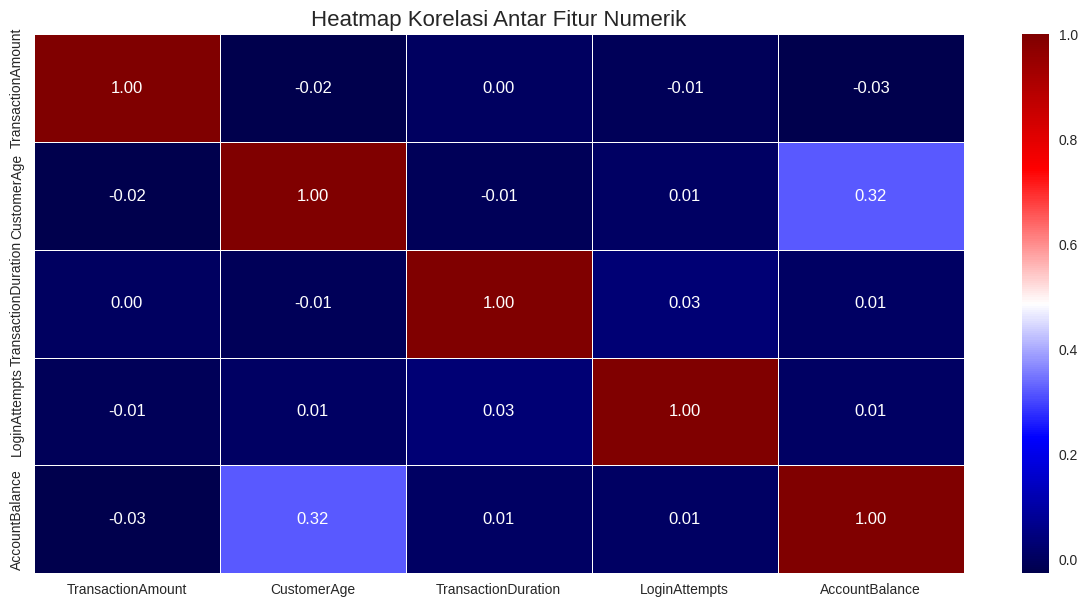

In [511]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
numerical_features = df.select_dtypes(include=np.number)
correlation_matrix = numerical_features.corr()

plt.figure(figsize=(15, 7))
sns.heatmap(
  correlation_matrix,
  annot=True,
  cmap='seismic',
  fmt='.2f',
  linewidths=.5
)
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=16)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

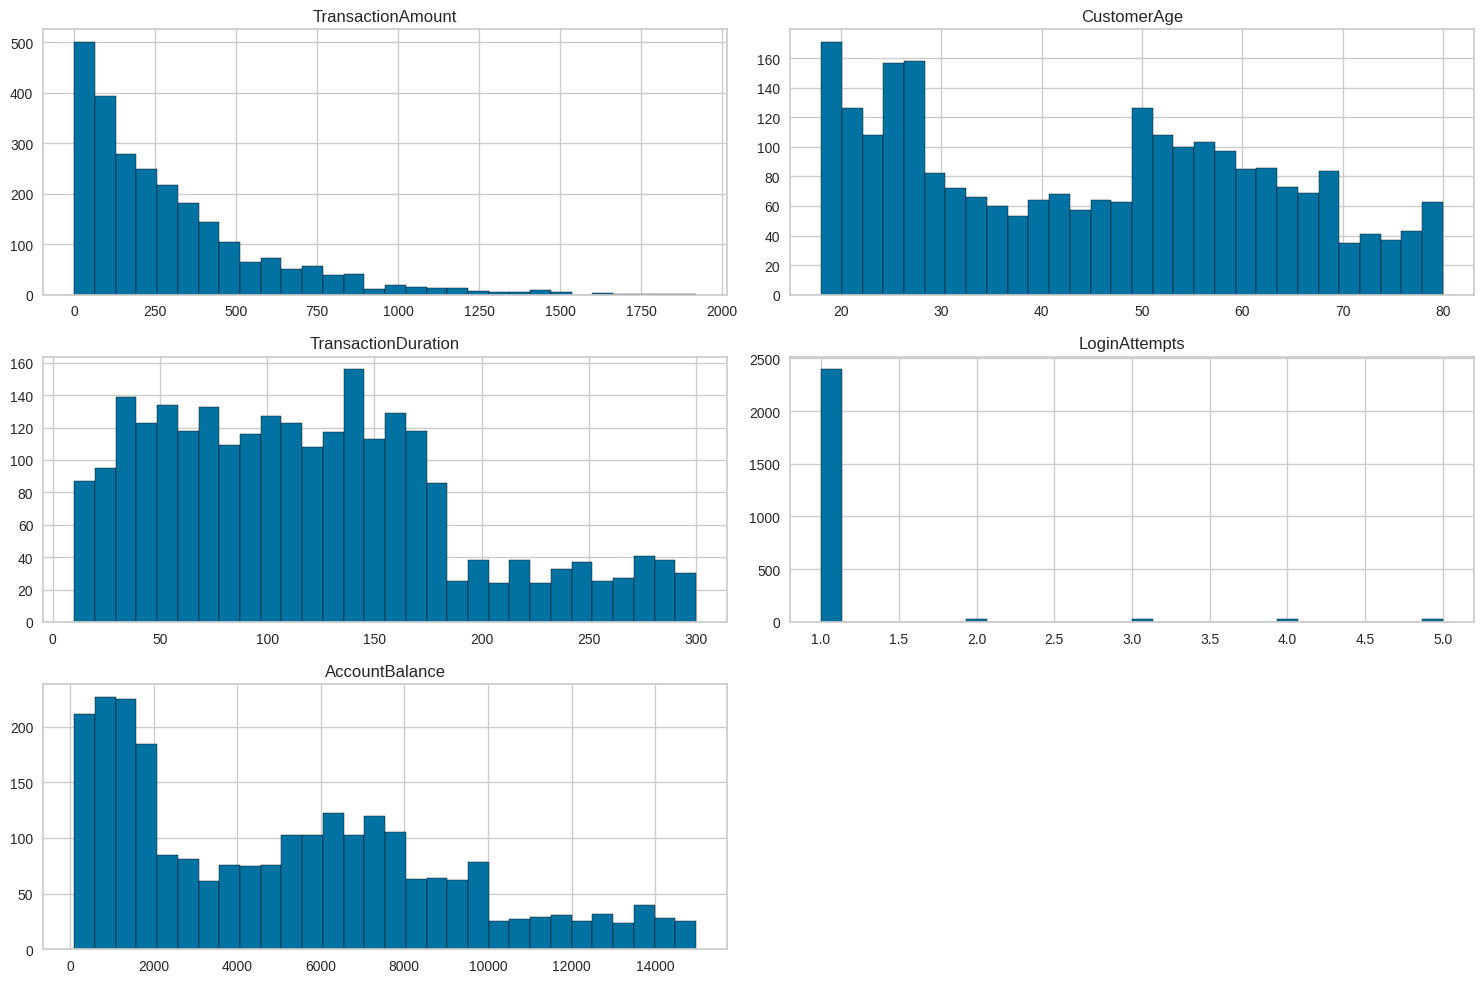

In [512]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
numerical_features.hist(
  figsize=(15, 10),
  bins=30,
  edgecolor='black'
)
plt.tight_layout()
plt.show

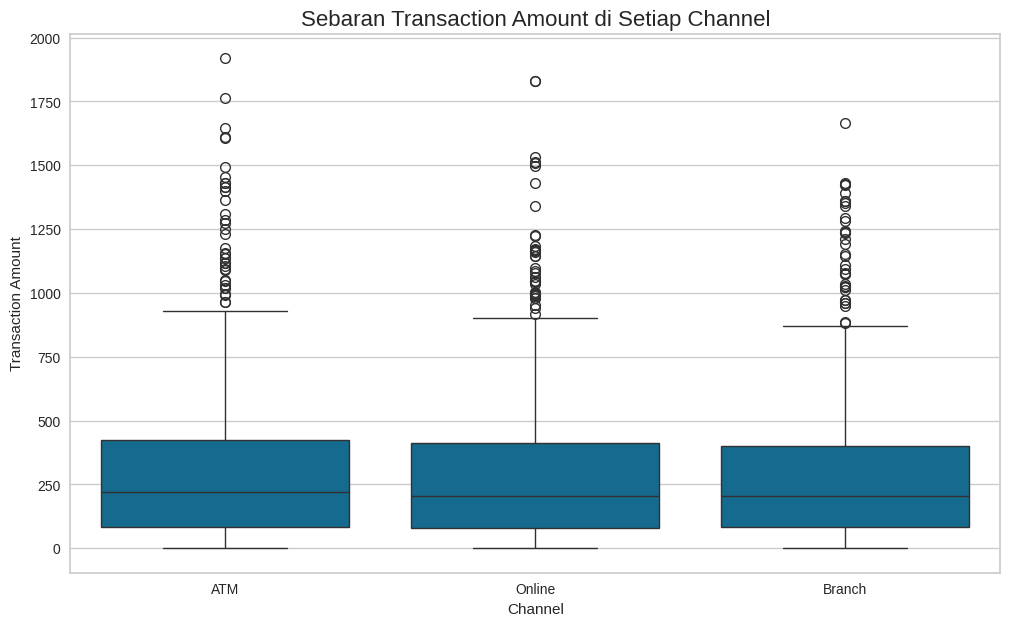

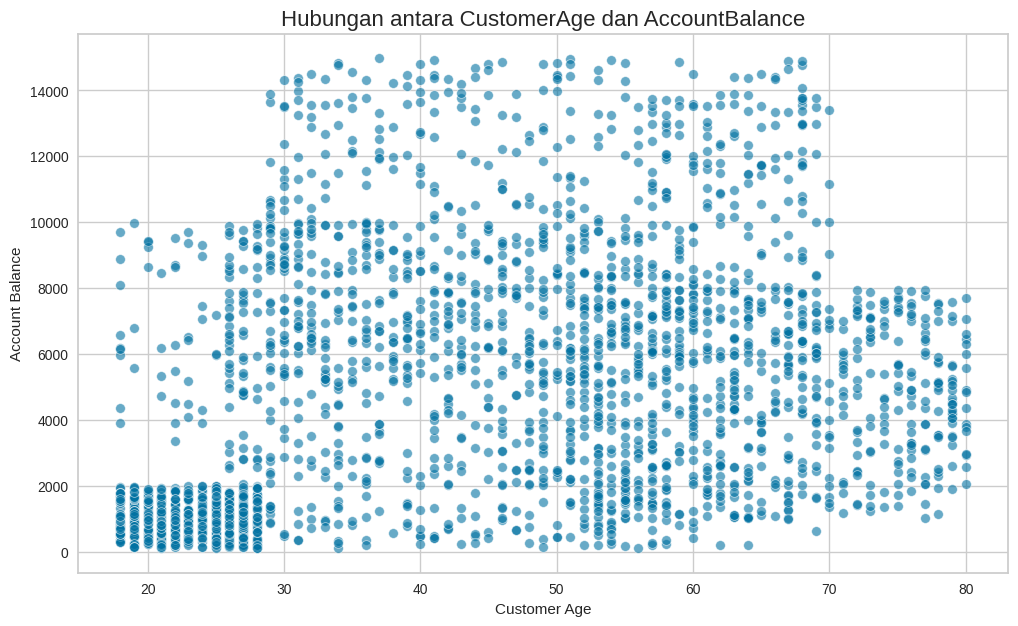

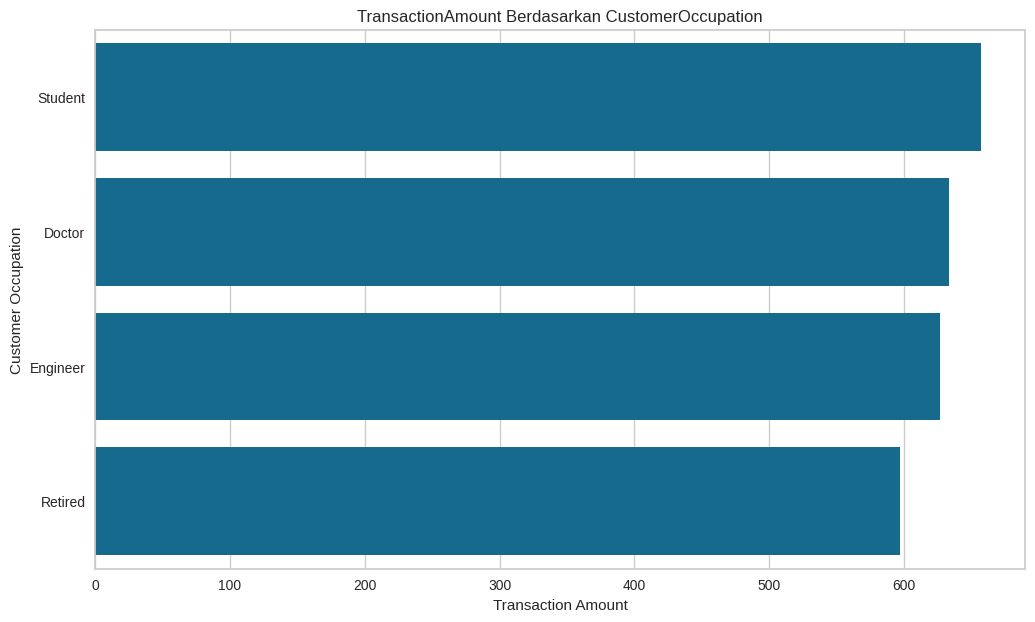

In [513]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
plt.figure(figsize=(12, 7))
sns.boxplot(x='Channel', y='TransactionAmount', data=df)
plt.title('Sebaran Transaction Amount di Setiap Channel', fontsize=16)
plt.ylabel('Transaction Amount')
plt.xlabel('Channel')
plt.show()

plt.figure(figsize=(12, 7))
sns.scatterplot(x='CustomerAge', y='AccountBalance', data=df, alpha=0.6)
plt.title('Hubungan antara CustomerAge dan AccountBalance', fontsize=16)
plt.xlabel('Customer Age')
plt.ylabel('Account Balance')
plt.show()

plt.figure(figsize=(12, 7))
sns.countplot(y='CustomerOccupation', data=df, order=df['CustomerOccupation'].value_counts().index)
plt.title('TransactionAmount Berdasarkan CustomerOccupation')
plt.xlabel('Transaction Amount')
plt.ylabel('Customer Occupation')
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [514]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

In [515]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [516]:
# Menghapus data duplikat menggunakan drop_duplicates().
df.drop_duplicates()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511,TX002512,AC00009,243.08,2023-02-14 16:21:23,Credit,Jacksonville,D000215,59.127.135.25,M041,Online,24.0,Student,93.0,1.0,131.25,2024-11-04 08:07:49
2513,NaN,AC00304,313.69,2023-03-10 16:35:33,Debit,Oklahoma City,D000211,53.131.194.183,M034,Branch,73.0,Retired,152.0,1.0,7093.68,2024-11-04 08:10:23
2523,TX001691,AC00442,12.18,2023-04-20 18:50:39,Debit,New York,D000326,190.152.148.249,M088,Branch,76.0,Retired,77.0,1.0,4909.24,2024-11-04 08:07:37
2524,TX000076,AC00239,232.12,2023-12-28 17:31:03,Debit,Omaha,D000073,156.173.170.140,M066,ATM,37.0,Engineer,51.0,1.0,6689.87,2024-11-04 08:09:17


In [517]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
df.drop(['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID'], axis=1, inplace=True)

In [518]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
df.fillna({ 'PreviousTransactionDate': df['TransactionDate'] }, inplace=True)
df.dropna(subset=['TransactionDate'], inplace=True)

for col in ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']:
  median_value = df[col].median()
  df.fillna({ col: median_value }, inplace=True)

for col in ['Location', 'Channel', 'CustomerOccupation', 'TransactionType']:
  mode_value = df[col].mode()[0]
  df.fillna({ col: mode_value }, inplace=True)

df.isnull().sum()

TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [519]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  
  if col in ['TransactionAmount', 'AccountBalance', 'TransactionDuration']:
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

  elif col in ['LoginAttempts']:
    pass

  elif col in ['CustomerAge']:
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

In [520]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.
age_bins = [0, 29, 59, 150]
age_labels = ['Young', 'Adult', 'Older']

df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=age_bins, labels=age_labels, right=True)

amount_bins = [0, 250, 1000, 5000, float('inf')]
amount_labels = ['Low', 'Medium', 'High', 'Very High']

df['AmountCategory'] = pd.cut(df['TransactionAmount'], bins=amount_bins, labels=amount_labels, right=True)

df_encoded = df.copy()

le = LabelEncoder()
df_encoded['AgeGroup_Encoded'] = le.fit_transform(df_encoded['AgeGroup'])
df_encoded['AmountCategory_Encoded'] = le.fit_transform(df_encoded['AmountCategory'])

df_encoded.drop(['AgeGroup', 'AmountCategory'], axis=1, inplace=True)

In [521]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.
categorical_cols = df_encoded.select_dtypes(include='object').columns

encoders = {}
for col in categorical_cols:
  le = LabelEncoder()
  df_encoded[col] = le.fit_transform(df_encoded[col])
  encoders[col] = le

df_encoded.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,AgeGroup_Encoded,AmountCategory_Encoded
0,14.09,680,1,36,0,70.0,0,81.0,1.0,5112.21,129,1,0
1,376.24,1178,1,15,0,68.0,0,141.0,1.0,13758.91,216,1,1
2,126.29,1262,1,23,2,19.0,3,56.0,1.0,1122.35,65,2,0
3,184.50,818,1,33,2,26.0,3,25.0,1.0,8569.06,187,2,0
4,13.45,1939,0,1,2,45.0,3,198.0,1.0,7429.40,40,0,0


In [522]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.
numerical_cols = df_encoded.select_dtypes(include=np.number).columns

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

df_encoded.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,AgeGroup_Encoded,AmountCategory_Encoded
0,-1.076499,-0.782920,0.533564,1.232819,-1.226183,1.426317,-1.340244,-0.550806,-0.204927,-0.002100,-0.695733,0.182405,-0.877862
1,0.374414,-0.089092,0.533564,-0.488098,-1.226183,1.313735,-1.340244,0.308078,-0.204927,2.227746,0.139512,0.182405,1.139131
2,-0.626982,0.027940,0.533564,0.167490,1.260877,-1.444512,1.306141,-0.908674,-0.204927,-1.031021,-1.310167,1.349893,-0.877862
3,-0.393770,-0.590654,0.533564,0.986973,1.260877,-1.050477,1.306141,-1.352431,-0.204927,0.889367,-0.138903,1.349893,-0.877862
4,-1.079063,0.971156,-1.874190,-1.635375,1.260877,0.019048,1.306141,1.124017,-0.204927,0.595467,-1.550180,-0.985082,-0.877862


In [523]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df_encoded.columns.tolist()

['TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate',
 'AgeGroup_Encoded',
 'AmountCategory_Encoded']

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [524]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df_encoded.describe()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,AgeGroup_Encoded,AmountCategory_Encoded
count,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03
mean,-3.681569e-17,2.548778e-17,-1.624846e-16,-1.415988e-16,-9.628718e-17,-5.805550e-17,-3.469170e-17,-2.265581e-17,1.699185e-16,-3.008974e-17,1.090311e-16,-4.106365e-17,6.088748e-17
std,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00
min,-1.131907e+00,-1.730316e+00,-1.874190e+00,-1.717323e+00,-1.226183e+00,-1.500803e+00,-1.340244e+00,-1.567152e+00,-2.049266e-01,-1.294347e+00,-1.934201e+00,-9.850824e-01,-8.778623e-01
25%,-8.017407e-01,-8.637275e-01,5.335637e-01,-8.158911e-01,-1.226183e+00,-9.941861e-01,-1.340244e+00,-8.084713e-01,-2.049266e-01,-9.276896e-01,-8.589423e-01,-9.850824e-01,-8.778623e-01
50%,-2.898046e-01,-1.318265e-03,5.335637e-01,3.592795e-03,1.734698e-02,1.904777e-02,4.240123e-01,-1.070495e-01,-2.049266e-01,-9.544356e-02,5.104461e-03,1.824054e-01,-8.778623e-01
75%,5.081072e-01,8.666639e-01,5.335637e-01,8.230766e-01,1.260877e+00,8.071185e-01,1.306141e+00,5.943723e-01,-2.049266e-01,6.507208e-01,8.787518e-01,1.349893e+00,1.139131e+00
max,2.472879e+00,1.730466e+00,5.335637e-01,1.724509e+00,1.260877e+00,1.989225e+00,1.306141e+00,2.584120e+00,6.516131e+00,2.542128e+00,1.742799e+00,1.349893e+00,1.139131e+00


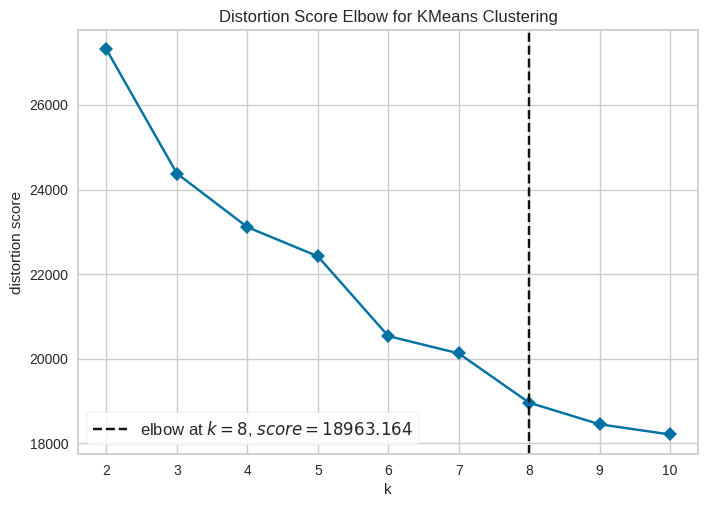

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [525]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
model = KMeans(random_state=42, n_init='auto')

visualizer = KElbowVisualizer(
  model,
  k=(2,11),
  timings=False,
  locate_elbow=True
)

visualizer.fit(df_encoded)
n_cluster = visualizer.elbow_value_

visualizer.show()

In [526]:
# Menggunakan algoritma K-Means Clustering
kmeans = KMeans(n_clusters=n_cluster, n_init='auto', random_state=42)

cluster_labels = kmeans.fit_predict(df_encoded)

df_encoded['Cluster'] = cluster_labels

df_no_pca_final = df_encoded.copy()
df_no_pca_final.rename(columns={'Cluster': 'Target'}, inplace=True)

Jalankan cell code ini untuk menyimpan model kamu.

In [527]:
# Menyimpan model menggunakan joblib
import joblib
joblib.dump(df_no_pca_final, "../models/kmeans_clustering.h5")

['../models/kmeans_clustering.h5']

In [528]:
# Menghitung dan menampilkan nilai Silhouette Score.
silhouette_avg = silhouette_score(df_encoded, cluster_labels)
print(f"Nilai Silhouette untuk k={n_cluster} adalah: {silhouette_avg:.4f}")

if silhouette_avg > 0.7:
  print("Interpretasi: Struktur cluster sangat baik dan padat.")
elif silhouette_avg > 0.5:
  print("Interpretasi: Struktur cluster cukup baik dan terpisah dengan wajar.")
elif silhouette_avg > 0.2:
  print("Interpretasi: Struktur cluster lemah atau tumpang tindih.")
else:
  print("Interpretasi: Struktur cluster sangat buruk atau tidak ditemukan.")

Nilai Silhouette untuk k=8 adalah: 0.2028
Interpretasi: Struktur cluster lemah atau tumpang tindih.


In [529]:
# Membuat visualisasi hasil clustering


In [530]:
# Membangun model menggunakan PCA.
n_pca_components=5
pca_reducer =PCA(n_components=n_pca_components)
principal_components = pca_reducer.fit_transform(df_encoded)
# Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
df_pca = pd.DataFrame(principal_components, columns=[f'PCA{i+1}' for i in range(n_pca_components)])
# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
kmeans_on_pca = KMeans(n_clusters=n_cluster, n_init='auto', random_state=42)
cluster_labels_pca = kmeans_on_pca.fit_predict(df_pca)
df_pca['Cluster'] = cluster_labels_pca

In [531]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(pca_reducer, "../models/kmeans_pca_clustering.h5")

['../models/kmeans_pca_clustering.h5']

In [532]:
silhouette_avg_pca = silhouette_score(df_encoded, cluster_labels_pca)
print(f"Nilai Silhouette untuk k={n_cluster} adalah: {silhouette_avg_pca:.4f}")

if silhouette_avg_pca > 0.7:
  print("Interpretasi: Struktur cluster sangat baik dan padat.")
elif silhouette_avg_pca > 0.5:
  print("Interpretasi: Struktur cluster cukup baik dan terpisah dengan wajar.")
elif silhouette_avg_pca > 0.2:
  print("Interpretasi: Struktur cluster lemah atau tumpang tindih.")
else:
  print("Interpretasi: Struktur cluster sangat buruk atau tidak ditemukan.")

Nilai Silhouette untuk k=8 adalah: 0.1869
Interpretasi: Struktur cluster sangat buruk atau tidak ditemukan.


# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**

In [533]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.
aggregations = {
  'TransactionAmount': ['mean', 'median', 'min', 'max'],
  'CustomerAge': ['mean', 'min', 'max'],
  'TransactionDuration': ['mean', 'min', 'max'],
  'LoginAttempts': ['mean', 'max', 'count'],
  'AccountBalance': ['mean', 'median', 'max']
}

cluster_analysis = df_encoded.groupby('Cluster').agg(aggregations).round(2)

cluster_analysis.columns = ['_'.join(col).strip() for col in cluster_analysis.columns.values]

cluster_analysis.to_csv('../reports/tables/cluster_analysis.csv', index=False)

cluster_analysis

,TransactionAmount_mean,TransactionAmount_median,TransactionAmount_min,TransactionAmount_max,CustomerAge_mean,CustomerAge_min,CustomerAge_max,TransactionDuration_mean,TransactionDuration_min,TransactionDuration_max,LoginAttempts_mean,LoginAttempts_max,LoginAttempts_count,AccountBalance_mean,AccountBalance_median,AccountBalance_max
Cluster,,,,,,,,,,,,,,,,
0,1.01,0.81,-0.12,2.47,-1.18,-1.50,-0.88,0.00,-1.57,2.50,-0.17,3.16,307,-0.86,-1.03,1.25
1,0.87,0.60,-0.13,2.47,0.47,-1.05,1.99,-0.01,-1.57,2.58,-0.18,1.48,580,0.29,0.28,2.54
2,-0.71,-0.74,-1.13,0.03,0.08,-0.99,1.43,0.07,-1.57,2.58,-0.18,1.48,252,1.36,1.25,2.53
3,-0.69,-0.74,-1.13,-0.13,-1.21,-1.50,-0.88,-0.02,-1.54,2.57,-0.15,3.16,380,-0.86,-1.03,1.19
4,-0.69,-0.74,-1.13,-0.14,0.49,-0.99,1.99,-0.32,-1.55,2.41,-0.19,1.48,272,-0.09,-0.05,1.25
5,0.01,-0.27,-1.12,2.47,0.52,-1.05,1.99,-0.07,-1.57,2.48,-0.18,1.48,376,0.36,0.32,2.53
6,-0.72,-0.76,-1.13,-0.08,0.76,-1.05,1.99,0.36,-1.54,2.56,-0.19,1.48,255,-0.16,-0.14,1.98
7,-0.05,-0.31,-1.13,2.47,0.09,-1.50,1.99,0.22,-1.55,2.46,4.95,6.52,87,0.13,-0.00,2.51


### Cluster 0: Transaksi Besar dari Saldo Rendah
- TransactionAmount_mean: 1.01 (Jauh di atas rata-rata)
- AccountBalance_mean: -0.86 (Di bawah rata-rata)
- LoginAttempts_count: 307
- Profil: Cluster ini berisi transaksi dengan nominal yang jauh lebih besar dari biasanya, namun berasal dari akun dengan saldo yang cenderung lebih rendah dari rata-rata.
- Tingkat Kecurigaan: Sedang hingga Tinggi 🟠. Transaksi besar dari akun bersaldo rendah adalah pola yang perlu diwaspadai.

### Cluster 1: Profil "Rata-rata" Terbesar
- TransactionAmount_mean: 0.87 (Di atas rata-rata)
- AccountBalance_mean: 0.29 (Sedikit di atas rata-rata)
- LoginAttempts_count: 580 (Cluster Terbesar)
- Profil: Ini adalah kelompok pengguna yang paling umum. Mereka melakukan transaksi sedikit di atas rata-rata dari akun dengan saldo yang juga sedikit di atas rata-rata.
- Tingkat Kecurigaan: Rendah 🟢. Ini kemungkinan besar adalah profil pengguna aktif yang normal.

### Cluster 2: Si Kaya yang Hemat
- TransactionAmount_mean: -0.71 (Jauh di bawah rata-rata)
- AccountBalance_mean: 1.36 (Jauh di atas rata-rata)
- LoginAttempts_count: 252
- Profil: Cluster ini unik, berisi transaksi bernominal sangat kecil yang berasal dari akun dengan saldo yang sangat tinggi.
- Tingkat Kecurigaan: Rendah 🟢. Ini bisa jadi profil nasabah kaya yang menggunakan akunnya untuk transaksi-transaksi kecil atau nasabah yang sangat berhati-hati.

### Cluster 3, 4, 5, 6: Kelompok Pengguna Normal Lainnya
- Keempat cluster ini memiliki statistik yang sangat mirip dan cenderung dekat dengan rata-rata (nilai antara -0.7 hingga 0.5).
- Profil: Mereka semua tampaknya mewakili variasi dari perilaku transaksi normal dengan nominal dan saldo di bawah atau sedikit di atas rata-rata.
- Tingkat Kecurigaan: Rendah 🟢.

### Cluster 7: Upaya Login Brutal! 🚩
- LoginAttempts_max: 6.52 (EKSTREM, JAUH PALING TINGGI)
- LoginAttempts_mean: 2.46 (JAUH PALING TINGGI)
- LoginAttempts_count: 87 (Cluster Terkecil)
- TransactionAmount_mean: -0.76 (Sangat rendah)
- Profil: Ini adalah cluster yang paling menonjol dan mencurigakan. Meskipun nilai transaksinya kecil, cluster ini dicirikan oleh upaya login yang sangat tinggi. Selain itu, ini adalah cluster dengan anggota paling sedikit, yang seringkali menjadi ciri khas kelompok anomali.
- Tingkat Kecurigaan: SANGAT TINGGI 🔴. Pola ini sangat cocok dengan percobaan brute force atau upaya pengambilalihan akun.

## **b. Interpretasi Hasil Clustering dengan PCA**

In [534]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.
df_analysis_pca = df_encoded.copy()
df_analysis_pca['Cluster'] = cluster_labels_pca

aggregations_pca = {
  'TransactionAmount': ['mean', 'median', 'min', 'max'],
  'CustomerAge': ['mean', 'min', 'max'],
  'TransactionDuration': ['mean', 'min', 'max'],
  'LoginAttempts': ['mean', 'max', 'count'],
  'AccountBalance': ['mean', 'median', 'max']
}

cluster_analysis_pca = df_encoded.groupby('Cluster').agg(aggregations_pca).round(2)

cluster_analysis_pca.columns = ['_'.join(col).strip() for col in cluster_analysis_pca.columns.values]

cluster_analysis_pca

,TransactionAmount_mean,TransactionAmount_median,TransactionAmount_min,TransactionAmount_max,CustomerAge_mean,CustomerAge_min,CustomerAge_max,TransactionDuration_mean,TransactionDuration_min,TransactionDuration_max,LoginAttempts_mean,LoginAttempts_max,LoginAttempts_count,AccountBalance_mean,AccountBalance_median,AccountBalance_max
Cluster,,,,,,,,,,,,,,,,
0,1.01,0.81,-0.12,2.47,-1.18,-1.50,-0.88,0.00,-1.57,2.50,-0.17,3.16,307,-0.86,-1.03,1.25
1,0.87,0.60,-0.13,2.47,0.47,-1.05,1.99,-0.01,-1.57,2.58,-0.18,1.48,580,0.29,0.28,2.54
2,-0.71,-0.74,-1.13,0.03,0.08,-0.99,1.43,0.07,-1.57,2.58,-0.18,1.48,252,1.36,1.25,2.53
3,-0.69,-0.74,-1.13,-0.13,-1.21,-1.50,-0.88,-0.02,-1.54,2.57,-0.15,3.16,380,-0.86,-1.03,1.19
4,-0.69,-0.74,-1.13,-0.14,0.49,-0.99,1.99,-0.32,-1.55,2.41,-0.19,1.48,272,-0.09,-0.05,1.25
5,0.01,-0.27,-1.12,2.47,0.52,-1.05,1.99,-0.07,-1.57,2.48,-0.18,1.48,376,0.36,0.32,2.53
6,-0.72,-0.76,-1.13,-0.08,0.76,-1.05,1.99,0.36,-1.54,2.56,-0.19,1.48,255,-0.16,-0.14,1.98
7,-0.05,-0.31,-1.13,2.47,0.09,-1.50,1.99,0.22,-1.55,2.46,4.95,6.52,87,0.13,-0.00,2.51


### Cluster 0: Transaksi Besar dari Saldo Rendah
- TransactionAmount_mean: 1.01 (Jauh di atas rata-rata)
- AccountBalance_mean: -0.86 (Di bawah rata-rata)
- LoginAttempts_count: 307
- Profil: Sama seperti pada metode K-Means saja, PCA juga berhasil mengisolasi kelompok transaksi bernilai tinggi dari akun bersaldo relatif rendah.
- Tingkat Kecurigaan: Sedang hingga Tinggi 🟠. Konsistensi temuan ini menguatkan bahwa profil ini memang ada di data.

### Cluster 1 & 5: Profil "Rata-rata"
- Cluster 1 (count: 580) dan Cluster 5 (count: 376) keduanya menunjukkan nilai yang sangat dekat dengan rata-rata di hampir semua fitur.
- Profil: Ini adalah kelompok-kelompok besar yang mewakili perilaku pengguna normal atau rata-rata.
- Tingkat Kecurigaan: Rendah 🟢.

### Cluster 2: Si Kaya yang Hemat
- TransactionAmount_mean: -0.71 (Jauh di bawah rata-rata)
- AccountBalance_mean: 1.36 (Jauh di atas rata-rata)
- LoginAttempts_count: 252
- Profil: PCA juga secara konsisten menemukan kelompok nasabah dengan saldo sangat tinggi yang cenderung melakukan transaksi bernilai kecil.
- Tingkat Kecurigaan: Rendah 🟢.

### Cluster 3, 4, 6: Variasi Pengguna Normal
- Seperti pada metode sebelumnya, cluster-cluster ini menunjukkan variasi perilaku normal dengan nilai transaksi dan saldo yang berada di bawah rata-rata. Mereka tidak menunjukkan pola yang menonjol.
- Tingkat Kecurigaan: Rendah 🟢.

### Cluster 7: Upaya Login Brutal (Semakin Jelas!) 🚩
- LoginAttempts_max: 6.52 (Sangat Ekstrem)
- LoginAttempts_mean: 2.46 (Sangat Tinggi)
- LoginAttempts_count: 87 (Cluster Terkecil)
- Profil: Yang paling penting, PCA tidak hanya mempertahankan cluster anomali ini, tetapi mungkin juga membuatnya lebih terdefinisi (seperti yang ditunjukkan oleh peningkatan Silhouette Score). Ini adalah kelompok kecil dengan perilaku login yang sangat mencurigakan.
- Tingkat Kecurigaan: SANGAT TINGGI 🔴.

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [535]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df_no_pca_final_labeled = df_no_pca_final.copy()
df_no_pca_final_labeled.rename(columns={'Cluster': 'Target'}, inplace=True)

df_pca_final_labeled = df_pca.copy()
df_pca_final_labeled.rename(columns={'Cluster': 'Target'}, inplace=True)

In [536]:
# Simpan Data
df_no_pca_final_labeled.to_csv('../reports/tables/data_kmeans_clustering.csv', index=False)
df_pca_final_labeled.to_csv('../reports/tables/data_kmeans_clustering_pca.csv', index=False)

In [537]:
df_inverse = df_encoded.copy()

In [538]:
# inverse dataset ke rentang normal untuk numerikal
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])
# tampilkan dataset yang sudah di-inverse
df_inverse.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,AgeGroup_Encoded,AmountCategory_Encoded,Cluster
0,14.09,680.0,1.0,36.0,-1.110223e-16,70.0,0.0,81.0,1.0,5112.21,129.0,1.0,0.0,4
1,376.24,1178.0,1.0,15.0,-1.110223e-16,68.0,0.0,141.0,1.0,13758.91,216.0,1.0,1.0,1
2,126.29,1262.0,1.0,23.0,2.000000e+00,19.0,3.0,56.0,1.0,1122.35,65.0,2.0,0.0,3
3,184.50,818.0,1.0,33.0,2.000000e+00,26.0,3.0,25.0,1.0,8569.06,187.0,2.0,0.0,3
4,13.45,1939.0,0.0,1.0,2.000000e+00,45.0,3.0,198.0,1.0,7429.40,40.0,0.0,0.0,5


In [539]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
for col in categorical_cols:
    le = encoders[col]
    df_inverse[col] = le.inverse_transform(df_inverse[col].astype(int))
# tampilkan dataset yang sudah di-inverse
df_inverse.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,AgeGroup_Encoded,AmountCategory_Encoded,Cluster
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,1.0,0.0,4
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,1.0,1.0,1
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,2.0,0.0,3
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,2.0,0.0,3
4,13.45,2023-10-16 17:51:24,Credit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,0.0,0.0,5


In [540]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

final_aggregations = {
  'TransactionAmount': ['mean', 'median', 'min', 'max'],
  'CustomerAge': ['mean', 'min', 'max'],
  'Channel': lambda x: x.mode()[0],
  'TransactionType': lambda x: x.mode()[0]
}

analysis_human_readable = df_inverse.groupby('Cluster').agg(final_aggregations).round(2)
analysis_human_readable['Jumlah_Anggota'] = df_inverse['Cluster'].value_counts()

analysis_human_readable

TransactionAmount                         CustomerAge              \
                     mean  median     min     max        mean   min   max   
Cluster                                                                     
0                  535.25  486.08  252.31  900.02       23.63  18.0  29.0   
1                  500.45  433.72  250.01  900.02       52.99  26.0  80.0   
2                  104.60   98.60    0.45  290.86       46.17  27.0  70.0   
3                  110.68   98.68    0.26  249.34       23.22  18.0  29.0   
4                  110.19   99.03    0.84  247.58       53.33  27.0  80.0   
5                  284.42  215.76    2.03  900.02       53.90  26.0  80.0   
6                  102.21   93.82    0.32  263.99       58.13  26.0  80.0   
7                  270.44  204.70    1.93  900.02       46.21  18.0  80.0   

         Channel TransactionType Jumlah_Anggota  
        <lambda>        <lambda>                 
Cluster                                          
0            ATM           Debit            307  
1            ATM           Debit            580  
2            ATM           Debit            252  
3         Branch           Debit            380  
4            ATM           Debit            272  
5         Online          Credit            376  
6            ATM           Debit            255  
7         Online           Debit             87

### Cluster 0 & 1: Pengguna ATM Aktif
- Profil: Kedua cluster ini didominasi oleh transaksi melalui ATM dengan jenis transaksi Debit.
- Cluster 0: Terdiri dari nasabah usia muda (rata-rata 23.6 tahun) dengan jumlah transaksi yang cukup tinggi (rata-rata 535.25).
- Cluster 1: Terdiri dari nasabah usia lebih tua (rata-rata 52.9 tahun) dengan jumlah transaksi serupa (rata-rata 500.45). Ini adalah cluster terbesar dengan 580 anggota.
- Tingkat Kecurigaan: Rendah 🟢. Ini adalah profil pengguna ATM yang normal dan aktif, dibedakan berdasarkan demografi usia.

### Cluster 2, 3, 4, 6: Pengguna Transaksi Rendah & Berhati-hati
- Profil: Keempat cluster ini memiliki kesamaan, yaitu rata-rata TransactionAmount yang sangat rendah (berkisar antara 102 hingga 110).
- Cluster 2, 4, 6: Didominasi oleh pengguna ATM dengan jenis Debit.
- Cluster 3: Unik karena didominasi oleh transaksi di Branch (kantor cabang), yang menunjukkan preferensi untuk transaksi tatap muka.
- Tingkat Kecurigaan: Sangat Rendah 🟢. Ini adalah kelompok pengguna dengan volume transaksi rendah, kemungkinan besar adalah nasabah yang jarang bertransaksi atau sangat berhati-hati.

### Cluster 5: Pengguna Online Aktif dengan Transaksi Kredit
- Profil: Cluster ini menonjol karena mayoritas transaksinya dilakukan secara Online dengan jenis transaksi Credit (kartu kredit). Rata-rata transaksinya berada di tingkat menengah (284.42) dan berasal dari nasabah usia paruh baya (rata-rata 53.9 tahun).
- Tingkat Kecurigaan: Rendah ke Sedang 🟡. Transaksi kredit online secara umum memiliki risiko yang sedikit lebih tinggi, namun profil ini masih terlihat wajar. Ini bisa menjadi profil "pembelanja online" yang khas.

### Cluster 7: Kelompok Anomali 🚩
- Profil: Ini adalah cluster yang paling menarik dari sudut pandang deteksi penipuan.
- Jumlah Anggota: Ini adalah cluster terkecil dengan hanya 87 anggota. Cluster kecil seringkali merupakan tempat berkumpulnya anomali.
- Kanal: Didominasi oleh transaksi Online.
- Jumlah Transaksi: Memiliki rata-rata transaksi di tingkat menengah (270.44), namun ini bisa jadi menyesatkan. Jika kita kembali ke analisis sebelumnya, kita tahu bahwa cluster ini memiliki nilai LoginAttempts yang paling ekstrem.
- Tingkat Kecurigaan: Sangat Tinggi 🔴. Meskipun nilai transaksinya tidak paling tinggi, kombinasi dari ukuran clusternya yang kecil, dominasi transaksi online, dan (yang paling penting) riwayat upaya login yang gagal menjadikannya kandidat utama untuk cluster yang berisi aktivitas penipuan atau percobaan pengambilalihan akun.

In [541]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.

In [542]:
# Simpan Data
df_inverse.to_csv('../reports/tables/data_clustering_inverse.csv', index=False)

End of Code.